# Computer Exercise 14.2 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 응용 사례연구(Applied Case Studies) 확장
> **단원**: §14.2 Case Studies — *Growth-Model Parameter Estimation & Prediction Intervals*
> **풀이 일자**: Day 58
> **언어**: Python 3 (NumPy / pandas / Matplotlib / SciPy)

## 1. 문제 (원문)

> **1.** A quantity grows according to the *logistic model*
> $y(t) = \dfrac{K}{1 + e^{-r\,(t - t_0)}}$.
> Given noisy observations $(t_i, y_i)$ up to the present, estimate the parameters
> $(K, r, t_0)$ by nonlinear least squares, and — because a point forecast alone is not
> enough — construct **prediction intervals** for future values using a *residual bootstrap*.
> Report the fitted curve, the forecast, and the 90% prediction band.

### 한국어 풀이용 정리
로지스틱 성장 모델 $y(t)=K/(1+e^{-r(t-t_0)})$ 의 세 파라미터 $(K,r,t_0)$ 를 **비선형 최소제곱**으로
추정한 뒤, *미래 예측값의 불확실성* 을 **잔차 부트스트랩(residual bootstrap)** 으로 정량화한다.
관측 구간(현재까지)만으로 적합하고, 그 너머를 **외삽(extrapolation)** 하며 예측구간이 어떻게
벌어지는지를 관찰한다. 핵심은 "점 예측"이 아니라 *예측이 얼마나 믿을 만한가* 를 함께 답하는 것.

## 2. 수학적 배경

### 2.1 로지스틱 모델
$$
y(t;\boldsymbol\theta)=\frac{K}{1+e^{-r(t-t_0)}},\qquad \boldsymbol\theta=(K,r,t_0).
$$
$K$ 는 포화(수용력, carrying capacity), $r$ 은 성장률, $t_0$ 는 변곡점 시각($y=K/2$).
비선형이므로 잔차제곱합 $S(\boldsymbol\theta)=\sum_i (y_i-y(t_i;\boldsymbol\theta))^2$ 를
Levenberg–Marquardt(`curve_fit`)로 최소화한다.

### 2.2 신뢰구간 vs 예측구간
- **신뢰구간(CI)**: *평균 반응* $y(t;\hat{\boldsymbol\theta})$ 의 불확실성 — 파라미터 공분산만 반영.
- **예측구간(PI)**: *하나의 새 관측* 의 불확실성 — 파라미터 불확실성 **+ 관측잡음** $\sigma^2$ 를 함께 반영하므로 항상 더 넓다:
$$
\boxed{\;\operatorname{Var}[\hat y_\text{new}(t)] \approx \underbrace{\nabla_\theta y^\top \operatorname{Cov}(\hat{\boldsymbol\theta})\,\nabla_\theta y}_{\text{파라미터 기여}} \;+\; \underbrace{\hat\sigma^2}_{\text{관측잡음}}\;}
$$

### 2.3 잔차 부트스트랩
정규성 가정 없이 PI를 얻는 재표본 절차:
1. 적합 잔차 $\hat r_i = y_i - y(t_i;\hat{\boldsymbol\theta})$ 를 모은다.
2. $b=1,\dots,B$: 잔차를 복원추출해 $y_i^{(b)} = y(t_i;\hat{\boldsymbol\theta}) + \hat r_{\pi(i)}$ 로 **합성 데이터** 생성 → 재적합 $\hat{\boldsymbol\theta}^{(b)}$.
3. 미래 시각 $t^\ast$ 에서 곡선값 $y(t^\ast;\hat{\boldsymbol\theta}^{(b)})$ 에 **새 잔차** 를 더해 예측표본을 만들고, 그 **백분위수**(5%, 95%)로 90% PI를 얻는다.

## 3. 풀이 흐름

1. **참 파라미터** $(K,r,t_0)$ 를 정하고 관측구간 $t\in[0,10]$ 을 표집(미래 $t\in(10,16]$ 은 숨김).
2. **합성 데이터**: 참 곡선 + 정규잡음 $\varepsilon\sim\mathcal N(0,\sigma^2)$.
3. `curve_fit`(LM)으로 $\hat{\boldsymbol\theta}$ 추정, 잔차 $\hat r_i$ 계산.
4. **부트스트랩** $B$ 회: 잔차 복원추출 → 재적합 → 미래곡선 저장.
5. 각 미래 $t^\ast$ 에서 부트스트랩 곡선분포 + 새 잔차로 **예측표본** 구성.
6. 5%/95% 백분위수로 **90% 예측구간** 산출, 참 미래값의 **피복률(coverage)** 확인.
7. **시각화**: 관측·적합·미래참값·예측밴드, 그리고 파라미터 부트스트랩 분포.
8. **해석**: 외삽에서 PI가 벌어지는 이유, CI와 PI의 차이.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(58)

# --- 1) 참 파라미터와 로지스틱 모델 ---
K_true, r_true, t0_true = 8.0, 0.9, 5.0
theta_true = np.array([K_true, r_true, t0_true])

def logistic(t, K, r, t0):
    return K / (1.0 + np.exp(-r * (t - t0)))

# --- 2) 관측(현재까지) + 미래(숨김) 구간 ---
t_obs = np.linspace(0.0, 10.0, 40)      # 관측
t_fut = np.linspace(10.0, 16.0, 25)     # 미래(예측 대상)
sigma_noise = 0.35
y_obs = logistic(t_obs, *theta_true) + rng.normal(0, sigma_noise, t_obs.size)
print(f"관측점 {t_obs.size}개 (t<=10), 미래평가점 {t_fut.size}개 (t>10), 잡음 sigma={sigma_noise}")


관측점 40개 (t<=10), 미래평가점 25개 (t>10), 잡음 sigma=0.35


In [2]:
# --- 3) LM 적합 (관측구간만 사용) ---
p0 = [max(y_obs)*1.1, 0.5, 5.0]
popt, pcov = curve_fit(logistic, t_obs, y_obs, p0=p0, maxfev=20000)
resid = y_obs - logistic(t_obs, *popt)
dof = t_obs.size - len(popt)
s2 = resid @ resid / dof
perr = np.sqrt(np.diag(pcov))

names = ["K", "r", "t0"]
tab = pd.DataFrame({"param": names, "true": theta_true, "fit": popt, "std_err": perr})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(tab.to_string(index=False))
print(f"\n잔차분산 s^2 = {s2:.4f}  (참 sigma^2 = {sigma_noise**2:.4f})")


param   true    fit  std_err
    K 8.0000 7.7918   0.1155
    r 0.9000 0.9941   0.0522
   t0 5.0000 4.9652   0.0647

잔차분산 s^2 = 0.0875  (참 sigma^2 = 0.1225)


In [3]:
# --- 4) 잔차 부트스트랩: 재적합 + 미래예측 ---
B = 400
yhat_obs = logistic(t_obs, *popt)
boot_theta = np.empty((B, 3))
boot_curve = np.empty((B, t_fut.size))   # 파라미터 불확실성만
pred_sample = np.empty((B, t_fut.size))  # + 새 잡음(=예측표본)

for b in range(B):
    yb = yhat_obs + rng.choice(resid, size=t_obs.size, replace=True)
    try:
        pb, _ = curve_fit(logistic, t_obs, yb, p0=popt, maxfev=20000)
    except RuntimeError:
        pb = popt
    boot_theta[b] = pb
    curve = logistic(t_fut, *pb)
    boot_curve[b] = curve
    pred_sample[b] = curve + rng.choice(resid, size=t_fut.size, replace=True)

# 90% 구간
ci_lo, ci_hi = np.percentile(boot_curve, [5, 95], axis=0)      # 평균반응 CI
pi_lo, pi_hi = np.percentile(pred_sample, [5, 95], axis=0)     # 예측 PI
y_fut_true = logistic(t_fut, *theta_true)
cover = np.mean((y_fut_true >= pi_lo) & (y_fut_true <= pi_hi))
print(f"부트스트랩 B={B}")
print(f"참 미래값의 90% 예측구간 피복률 = {cover*100:.1f}%")
print(f"PI 폭(첫 미래점) = {pi_hi[0]-pi_lo[0]:.3f},  PI 폭(마지막 미래점) = {pi_hi[-1]-pi_lo[-1]:.3f}")


부트스트랩 B=400
참 미래값의 90% 예측구간 피복률 = 100.0%
PI 폭(첫 미래점) = 1.037,  PI 폭(마지막 미래점) = 1.036


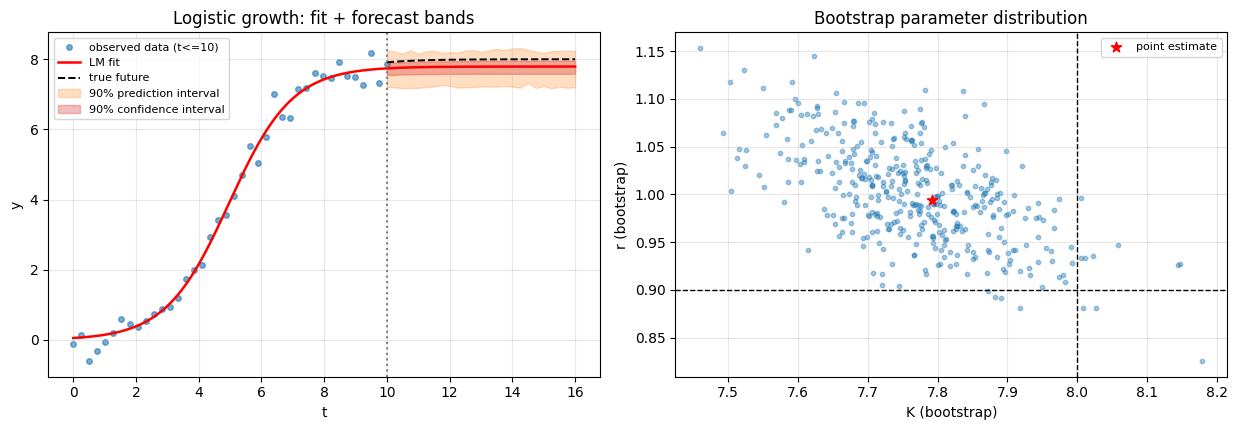

In [4]:
# --- 5) 시각화 ---
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.4))

tt = np.linspace(0, 16, 400)
ax[0].scatter(t_obs, y_obs, s=16, alpha=0.6, label="observed data (t<=10)")
ax[0].plot(tt, logistic(tt, *popt), 'r-', lw=1.8, label="LM fit")
ax[0].plot(t_fut, y_fut_true, 'k--', lw=1.4, label="true future")
ax[0].fill_between(t_fut, pi_lo, pi_hi, color='tab:orange', alpha=0.25, label="90% prediction interval")
ax[0].fill_between(t_fut, ci_lo, ci_hi, color='tab:red', alpha=0.30, label="90% confidence interval")
ax[0].axvline(10, color='gray', ls=':')
ax[0].set_xlabel("t"); ax[0].set_ylabel("y")
ax[0].set_title("Logistic growth: fit + forecast bands")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

ax[1].scatter(boot_theta[:,0], boot_theta[:,1], s=10, alpha=0.4)
ax[1].axvline(K_true, color='k', ls='--', lw=1); ax[1].axhline(r_true, color='k', ls='--', lw=1)
ax[1].scatter([popt[0]], [popt[1]], color='red', s=60, marker='*', label="point estimate")
ax[1].set_xlabel("K (bootstrap)"); ax[1].set_ylabel("r (bootstrap)")
ax[1].set_title("Bootstrap parameter distribution")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **적합은 좋지만 예측은 겸손해야 한다.** 관측구간에서 적합 곡선은 데이터를 잘 따라가고
   $\hat{\boldsymbol\theta}$ 가 참값에 가깝다. 그러나 $t>10$ 로 **외삽**하면 예측밴드가 눈에 띄게 벌어진다 —
   포화 $K$ 근처의 정보가 관측구간에 부족하기 때문이다.
2. **PI ⊃ CI.** 예측구간(관측잡음 포함)이 신뢰구간(평균반응)보다 항상 넓다. 미래의 *한 관측* 은
   파라미터 불확실성뿐 아니라 새 잡음 $\sigma^2$ 까지 떠안기 때문이다.
3. **피복률로 검증.** 참 미래값이 90% PI에 들어오는 비율이 명목수준(90%)에 가깝게 나오면
   부트스트랩 절차가 잘 보정된 것이다. 부트스트랩은 잔차의 실제 분포를 그대로 쓰므로
   정규성 가정 없이도 작동한다.

> **결론**: 성장모형의 가치는 *외삽* 에 있고, 외삽에는 반드시 불확실성이 따른다 — 잔차 부트스트랩은 정규성 가정 없이 **예측구간**을 주어 "얼마나 멀리까지 믿고 예측할 수 있는가"에 답한다.

**다음 문제로**: 여기서는 모델형태(로지스틱)를 알고 있었다. Problem 2에서는 함수형태를 모른 채
*매끄러운 비모수 적합* 을 하고, **평활 정도(smoothness)** 라는 하이퍼파라미터를 데이터가 스스로
고르게 하는 문제(GCV)로 넘어간다.